In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, spherical_yn
from scipy.interpolate import interp1d

c_const = 299792458
eps0_const = 1 / (4 * np.pi * c_const ** 2) * 1e7
mu0_const = 4 * np.pi * 1e-7

In [3]:
from scipy.interpolate import interp1d
import os
from pathlib import Path

def get_interpolate(mat):
    """Return interpolation function for material dielectric function."""
    files = {
        'Au': 'materials/nkAu.csv',
        'HfN': 'materials/nkHfN.csv',
        'TiN': 'materials/nkTiN.csv',
        'ZrN': 'materials/nkZrN.csv',
    }

    if mat not in files:
        raise ValueError(f"Unknown material: {mat}")

    base_dir = Path(__file__).resolve().parent if '__file__' in globals() else Path.cwd()
    file_path = base_dir / files[mat]

    data = np.loadtxt(file_path, delimiter=',', skiprows=1)

    n_interp = interp1d(data[:, 0], data[:, 1])
    k_interp = interp1d(data[:, 0], data[:, 2])

    return lambda wl: (n_interp(wl * 1e-3) + 1j * k_interp(wl * 1e-3))**2

In [4]:
def spherical_hn(n, x, derivative=False):
    if derivative == True:
        return spherical_jn(n, x, derivative=True) + 1j * spherical_yn(n, x, derivative=True)
    return spherical_jn(n, x) + 1j * spherical_yn(n, x)


def alpha_E_H(wl, R, eps_p, eps_m = 1):
    if callable(eps_p):
        eps3 = eps_p(wl)
    else:
        eps3 = eps_p
    n_m = np.sqrt(eps_m + 0j)
    n3 = np.sqrt(eps3 + 0j) / n_m
    x0 = R * 2 * np.pi / wl * n_m
    x1 = x0 * n3
    j1_x0 = spherical_jn(1, x0)
    j1_x1 = spherical_jn(1, x1)
    h1_x0 = spherical_hn(1, x0)
    j1_x0_d = spherical_jn(1, x0, derivative=True)
    j1_x1_d = spherical_jn(1, x1, derivative=True)
    h1_x0_d = spherical_hn(1, x0, derivative=True)

    dx0dj1x0 = j1_x0 + x0 * j1_x0_d
    dx1dj1x1 = j1_x1 + x1 * j1_x1_d
    dx0dh1x0 = h1_x0 + x0 * h1_x0_d

    a1 = (n3**2 * dx0dj1x0 * j1_x1 - dx1dj1x1 * j1_x0) / \
        (n3**2 * dx0dh1x0 * j1_x1 - dx1dj1x1 * h1_x0)
    b1 = (dx0dj1x0 * j1_x1 - dx1dj1x1 * j1_x0) / \
        (dx0dh1x0 * j1_x1 - dx1dj1x1 * h1_x0)

    k_m = 2 * np.pi / wl / 1e-9 * np.real_if_close(n_m)
    alpha_e = 6 * 1j * np.pi * a1 / k_m**3
    alpha_m = 6 * 1j * np.pi * b1 / k_m**3

    return alpha_e, alpha_m


def plane_wave(wl, alpha, amplitude, point):
    xnm, ynm, znm = point
    x = xnm*1e-9
    z = znm*1e-9
    k = 2*np.pi/wl/1e-9
    omega = 2*np.pi*c_const/wl/1e-9
    exp = np.exp(1j*k*np.sin(alpha)*x-1j*k*np.cos(alpha)*z)

    Ex = amplitude * np.cos(alpha) * exp 
    Ez = amplitude * np.sin(alpha) * exp 
    
    Hy = -k * amplitude * exp / omega / mu0_const
        

    E0 = np.array([[Ex],
                   [0],
                   [Ez]])
    H0 = np.array([[0],
                   [Hy],
                   [0]])

    return E0, H0

# Dipole model: polarizabilities form first order Mie coefficients

$$
\vec{p} = \varepsilon_0 \alpha_E \vec{E}, \quad \vec{m} = \alpha_H \vec{H}
$$

$$
\sigma_{\rm ext} = \sigma_{\rm abs} + \sigma_{\rm sc}
$$

$$
\sigma_{\rm ext} = k Im( \alpha_E + \alpha_H)
$$

$$
\sigma_{\rm sc} = \frac{k^4}{6 \pi} ( |\alpha_E|^2 + |\alpha_H|^2)
$$

In [6]:
def cross_sections(wl, R, eps_p, eps_m = (1.4)**2):
    alpha_e, alpha_m = alpha_E_H(wl, R, eps_p, eps_m)
    n_m = np.real_if_close(np.sqrt(eps_m + 0j))
    k = 2 * np.pi / wl / 1e-9 * n_m
    C_geom = (np.pi*(R*1e-9)**2)
    Csca = k**4/(6*np.pi) * (np.abs(alpha_e)**2 + np.abs(alpha_m)**2)/C_geom
    Cext = k * np.imag(alpha_e + alpha_m)/C_geom
    Cabs = Cext - Csca
    return Csca, Cext, Cabs

## Now compare with Mie-Calculator model

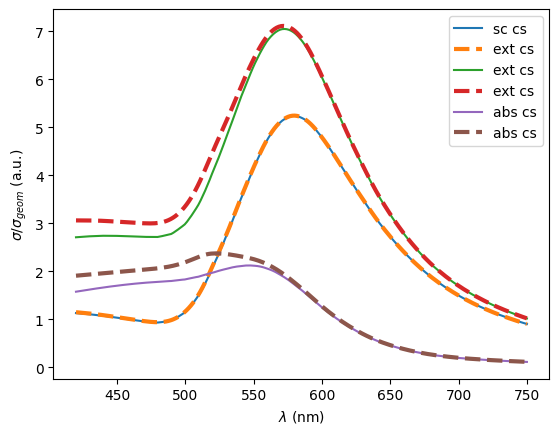

In [35]:
from matplotlib import pyplot as plt
data = np.genfromtxt('scattnlay-spectra.txt', skip_header=21, names=True, delimiter=', ')
wls_mie = data[data.dtype.names[0]]
Csc_mie = data['Qsca']
Cext_mie = data['Qext']
Cabs_mie = data['Qabs']

mat = 'Au'
R=50
eps_Au = get_interpolate(mat)
wls= np.linspace(420, 750, 200)
Csca, Cext, Cabs = cross_sections(wls, R, eps_Au, eps_m=(1.4)**2) #in water
plt.plot(wls, Csca, label='sc cs')
plt.plot(wls_mie, Csc_mie, label='ext cs', ls='--', lw=3)
plt.plot(wls, Cext, label='ext cs')
plt.plot(wls_mie, Cext_mie, label='ext cs', ls='--', lw=3)
plt.plot(wls, Cabs, label='abs cs')
plt.plot(wls_mie, Cabs_mie, label='abs cs', ls='--', lw=3)
plt.xlabel('$\\lambda$ (nm)')
plt.ylabel('$\\sigma/\\sigma_{geom}$ (a.u.)')
plt.legend()
plt.show()


Looks fine

## Now lets try different materials

Plots of cross sections for next particles:

Au in water (n=1.4), HfN in acetonitrile (n=1,34) , TiN in water (n=1.4), ZrN in aceton (n=1,36)

R = 50 nm

$\lambda \in [420, 950]$  (monochromatic light)


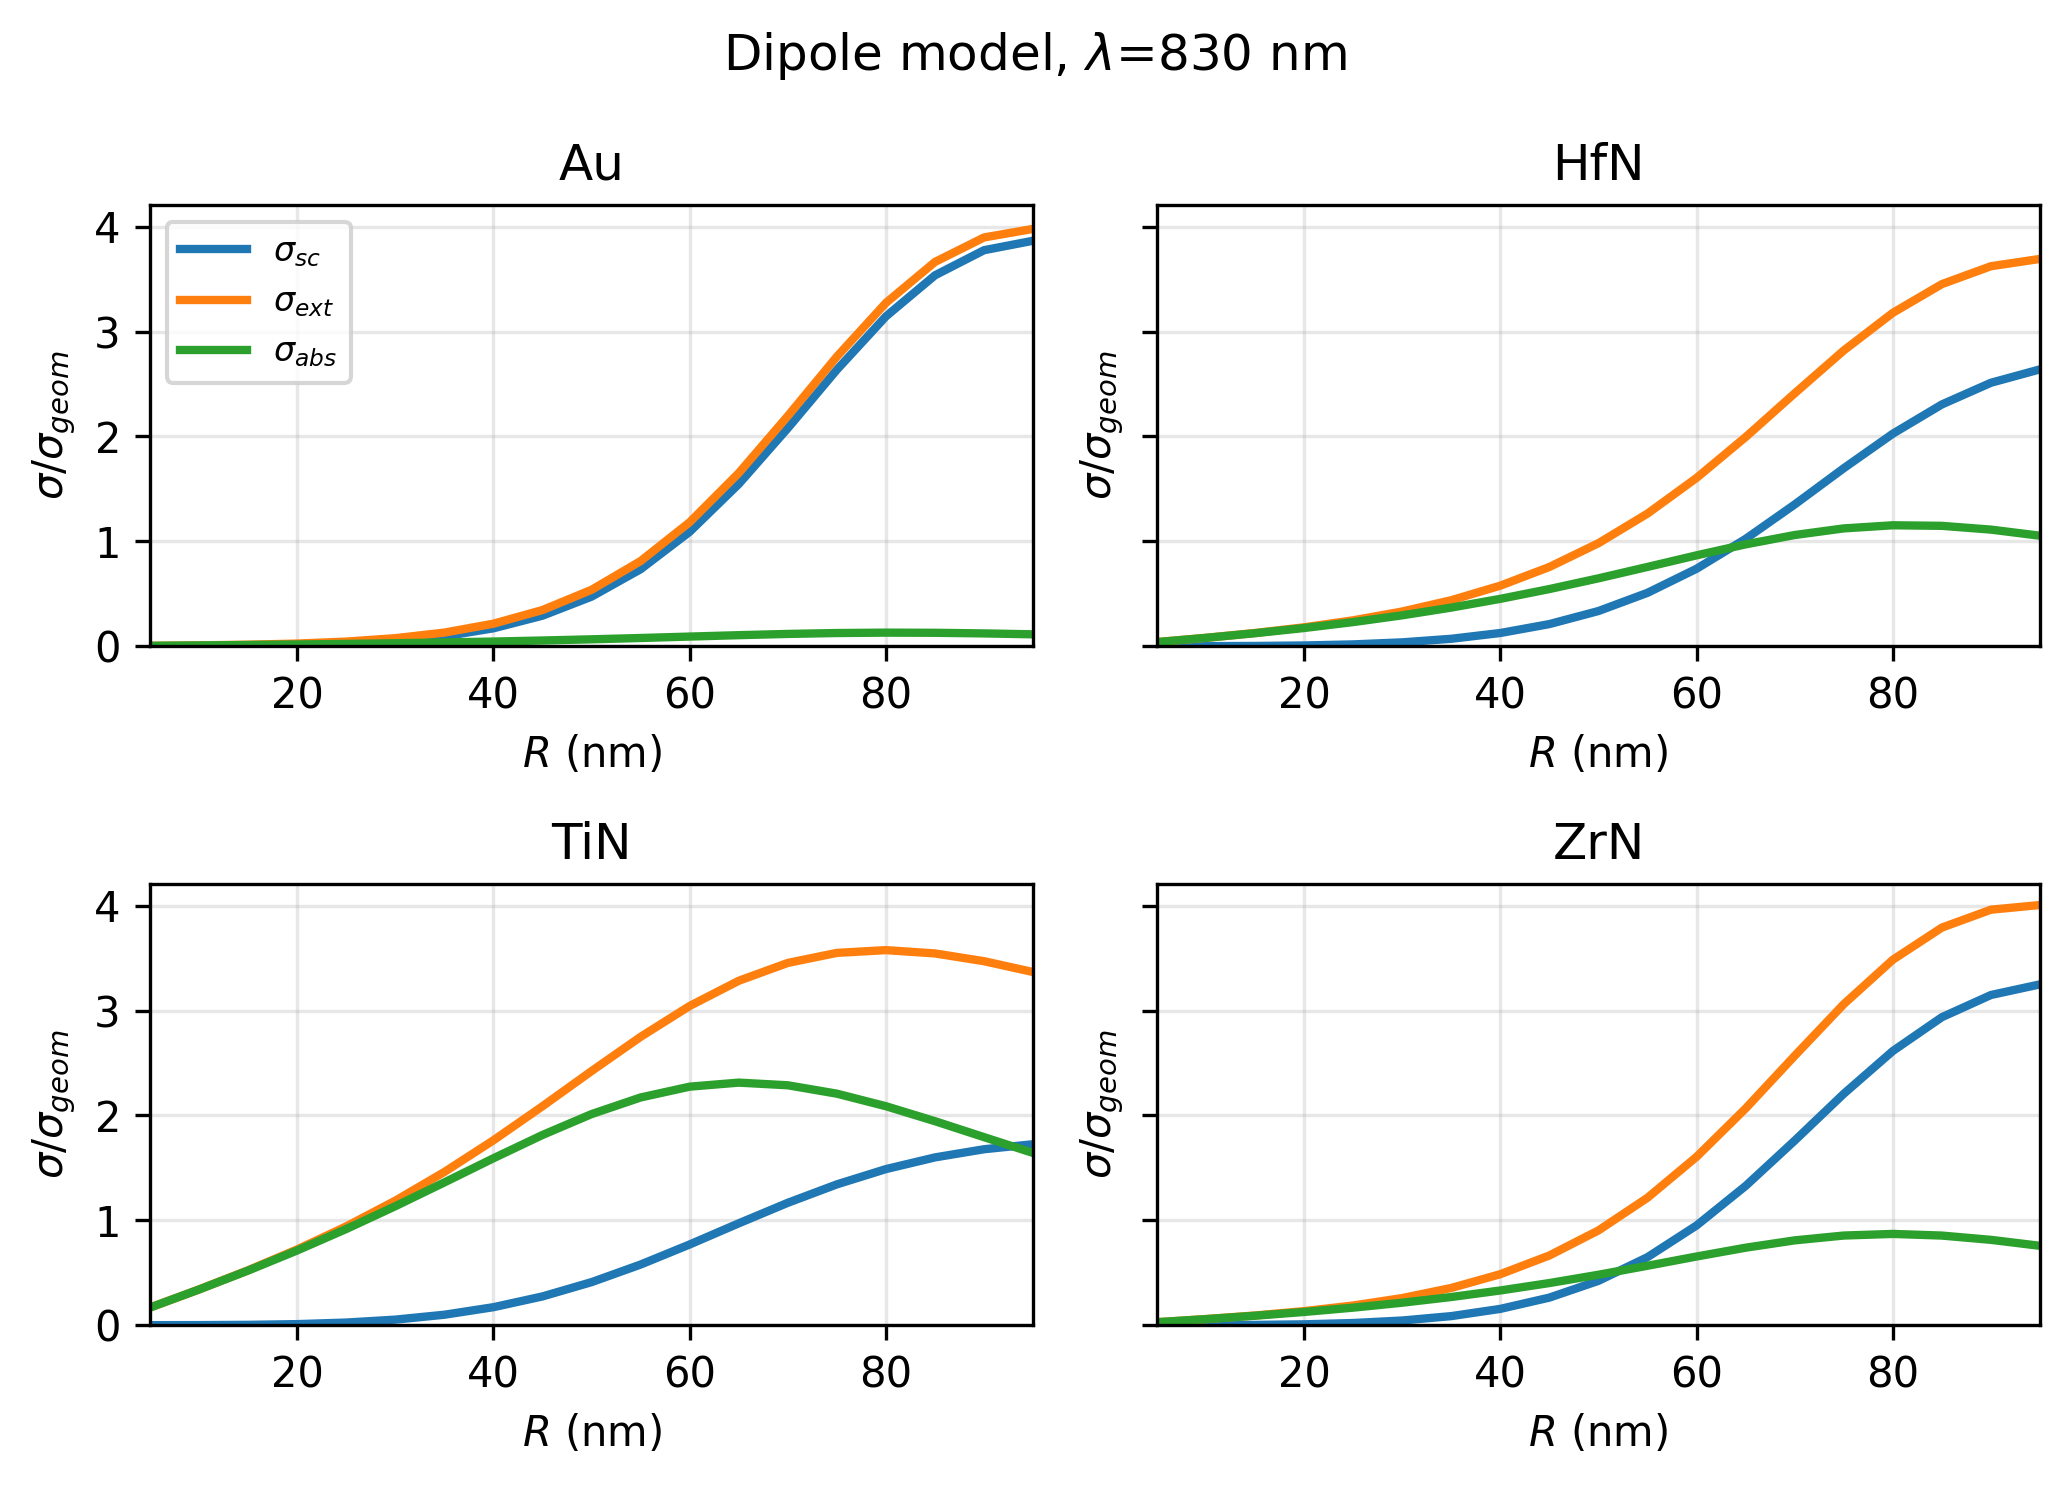

In [38]:
mats = ['Au', 'HfN', 'TiN', 'ZrN']
media = [1.4, 1.34, 1.4, 1.36]
# wls = np.linspace(420, 950, 250)
wl=830
Rs = np.arange(5,100, 5)

fig, axes = plt.subplots(2, 2, figsize=(7, 5), dpi=300, sharey=True)
axes = axes.ravel()

for i, mat in enumerate(mats):
    eps = get_interpolate(mat)
    Csca, Cext, Cabs = cross_sections(wl, Rs, eps, eps_m=media[i]**2)

    ax = axes[i]
    ax.plot(Rs, Csca, label='$\\sigma_{sc}$', lw=2)
    ax.plot(Rs, Cext, label='$\\sigma_{ext}$', lw=2)
    ax.plot(Rs, Cabs, label='$\\sigma_{abs}$', lw=2)
    ax.set_title(mat)
    ax.grid(alpha=0.3)

for ax in axes:
    ax.set_xlim(Rs[0], Rs[-1])
    ax.set_ylim(bottom=0)
    ax.set_xlabel('$R$ (nm)')
    ax.set_ylabel('$\\sigma/\\sigma_{geom}$')

axes[0].legend(loc='best', fontsize=8)
fig.suptitle(f'Dipole model, $\\lambda$={wl} nm')
plt.tight_layout()
plt.savefig('plots/cross_sections_monochromatic_comparison.png', dpi=300)
plt.show()

To analyze how good paricle absorbs light we can check relation between absorbtion cross-section and extinction cross-section.

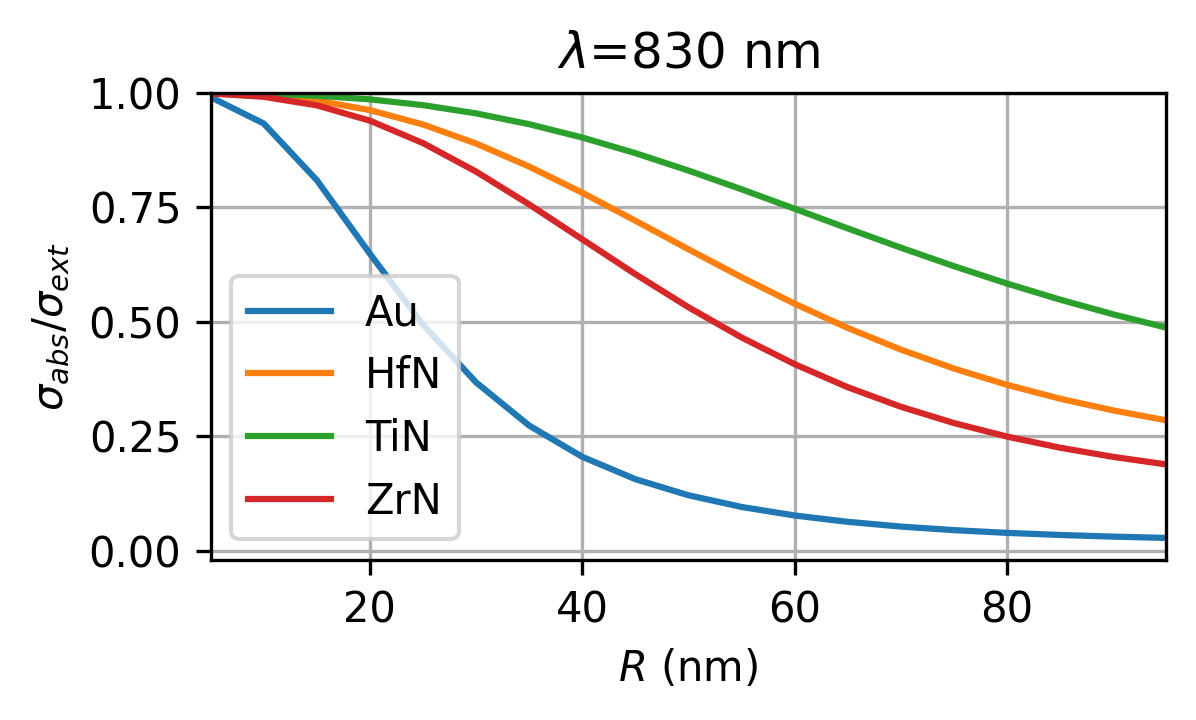

In [37]:
mats = ['Au', 'HfN', 'TiN', 'ZrN']
media = [1.4, 1.34, 1.4, 1.36]
wl = 830
R = np.arange(5,100, 5)

plt.figure(figsize=(4,2.5), dpi=300)

for i, mat in enumerate(mats):
    eps = get_interpolate(mat)
    Csca, Cext, Cabs = cross_sections(wl, R, eps, eps_m=media[i]**2)
    plt.plot(R, Cabs/Cext, label=f'{mat}')
    #np.savetxt(f'plots/cross_sections_{mat}_R.csv', np.column_stack((R, Csca, Cext, Cabs)), delimiter=',', header='R,Csca,Cext,Cabs', comments='')
    
plt.xlabel('$R$ (nm)')
plt.ylabel('$\\sigma_{abs}/\\sigma_{ext}$')
plt.title(f'$\\lambda$={wl} nm')
plt.legend()
plt.xlim(R[0], R[-1])
plt.ylim(None,1)
plt.grid()
plt.tight_layout()
plt.savefig('plots/abs_ext_ratio_monochromatic_comparison.png', dpi=300)
plt.show()

### Heatmap

Now lets plot 4 heatmaps (for each material) that would represent $\sigma_{abs}/\sigma_{ext}$ value from radius od the particles and incident wavelenght. 

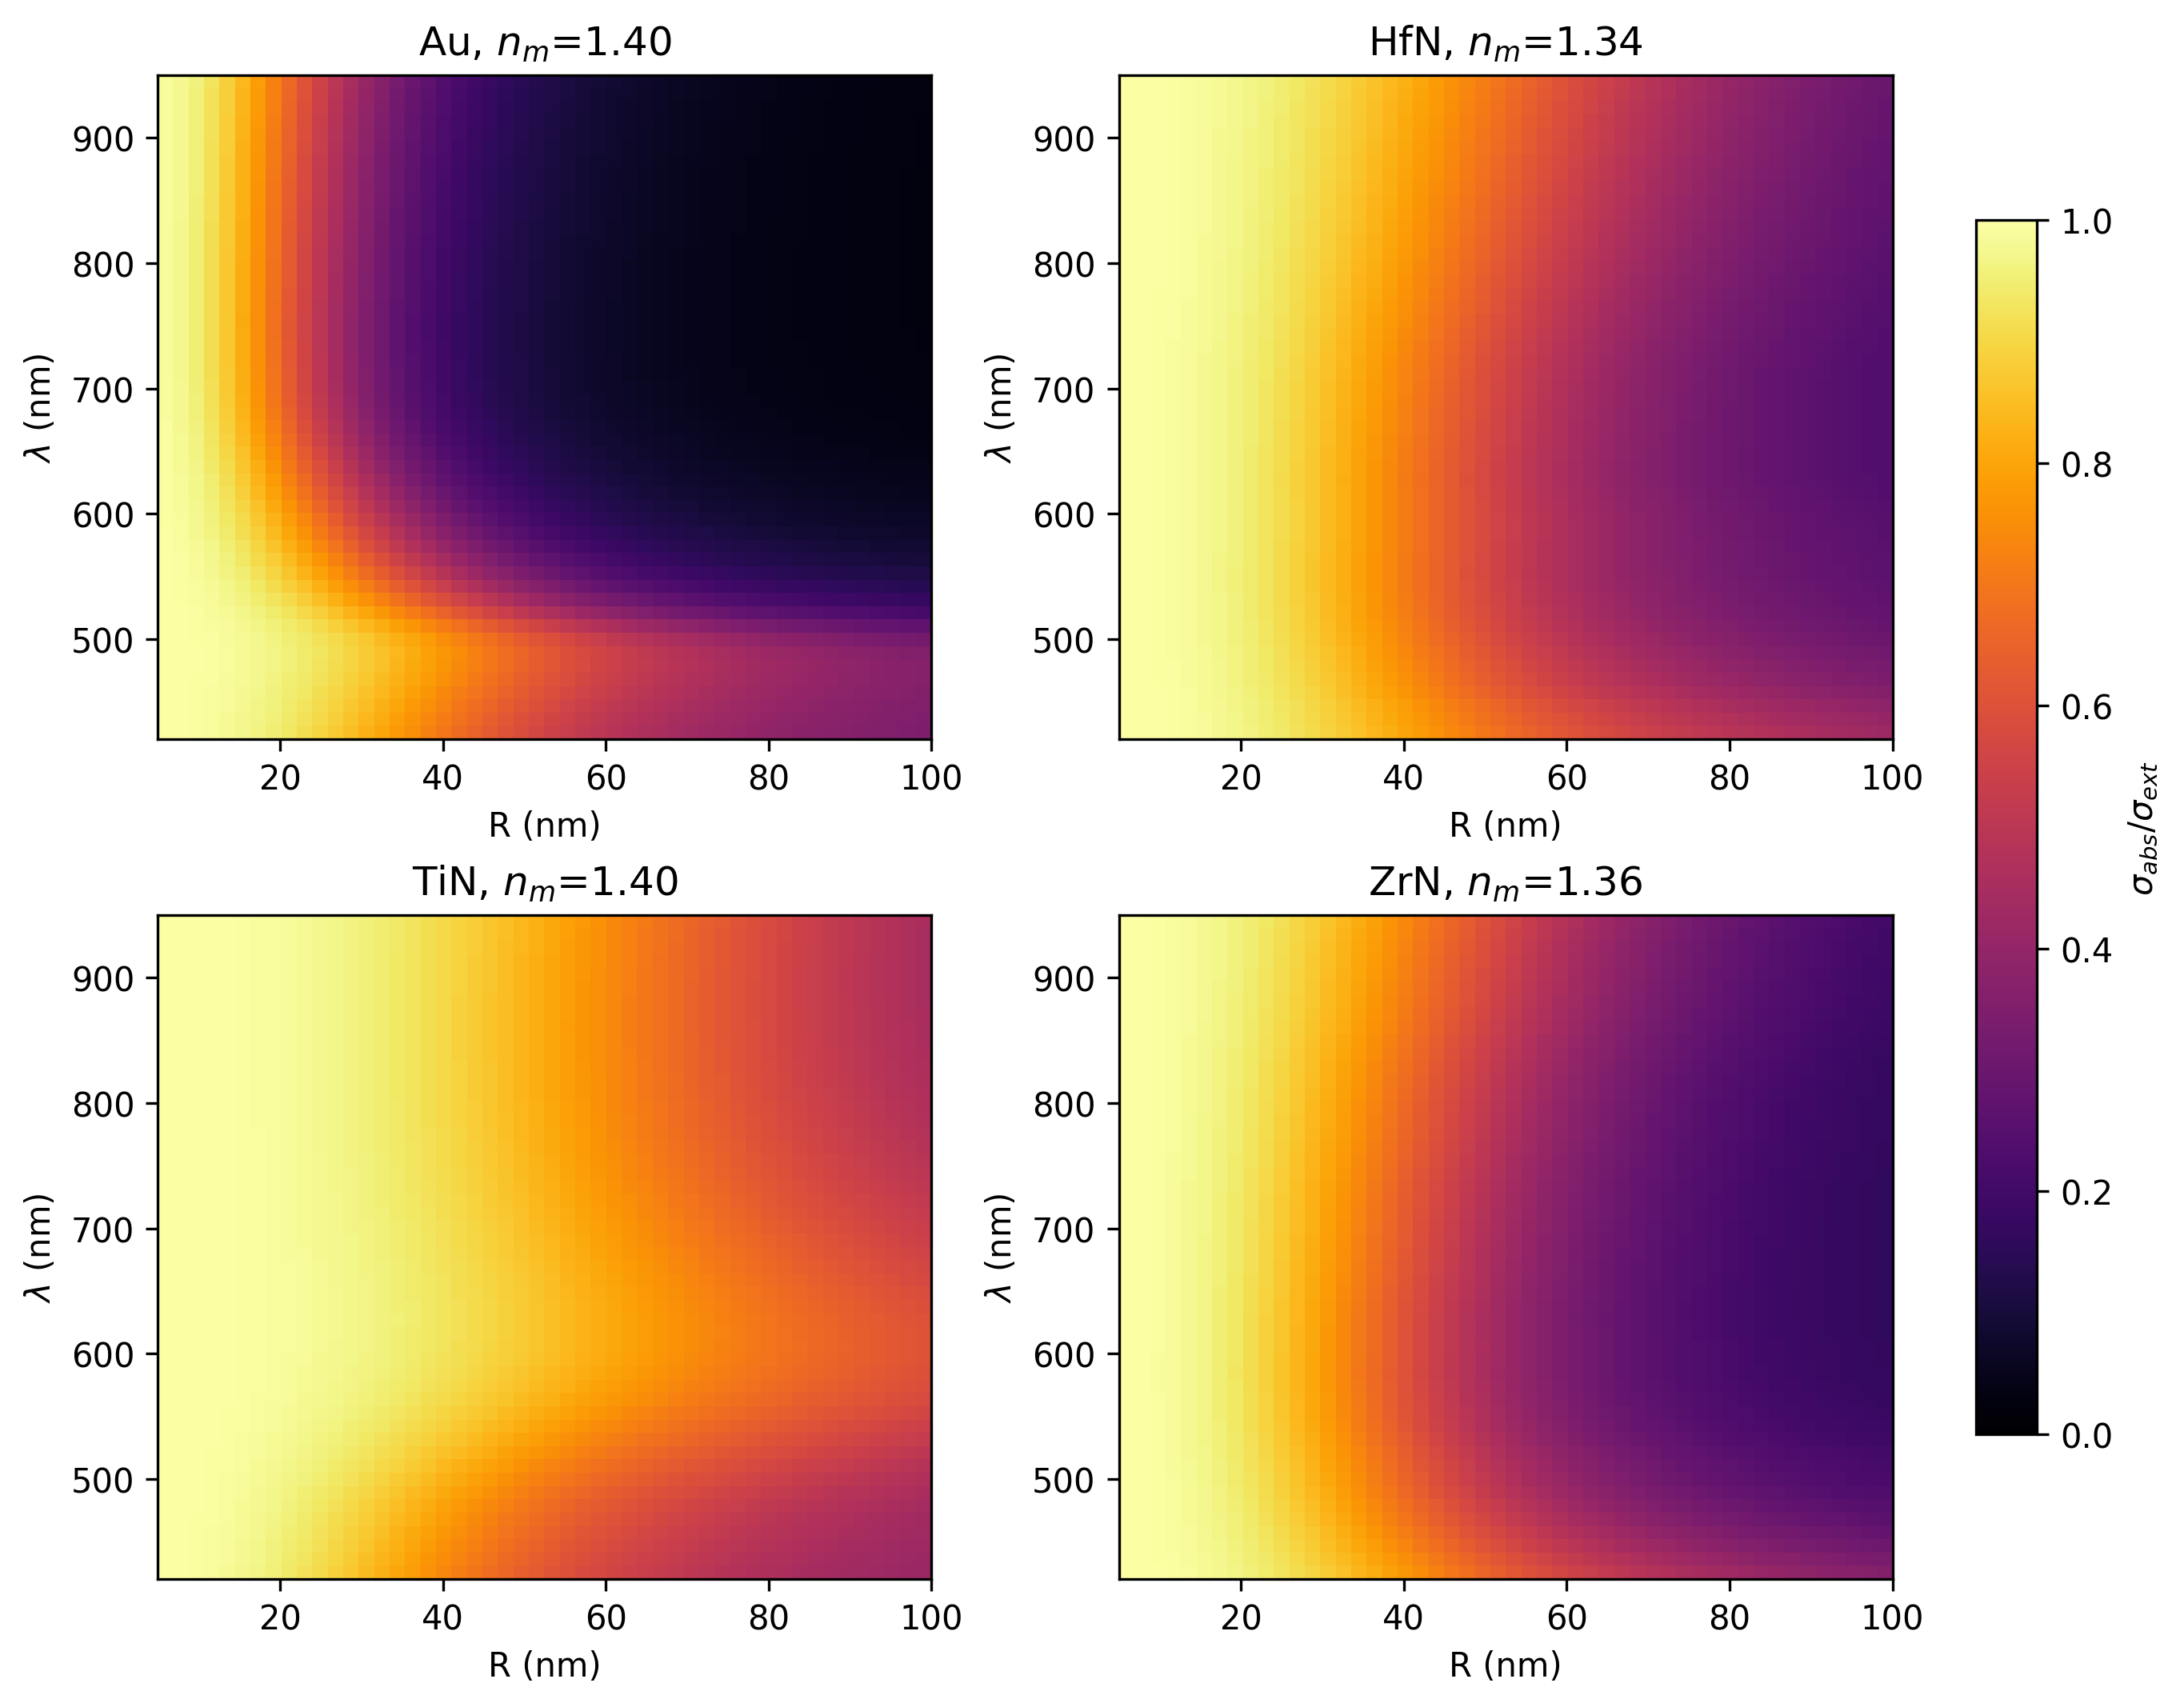

In [36]:
mats = ['Au', 'HfN', 'TiN', 'ZrN']
media = [1.4, 1.34, 1.4, 1.36]  # refractive index of surrounding medium
wls = np.linspace(420, 950, 50)   # nm
radii = np.linspace(5, 100, 50)  # nm

fig, axes = plt.subplots(
    2, 2, figsize=(9, 7), dpi=300, sharex=False, sharey=False, constrained_layout=True
)
axes = axes.ravel()

im = None
for i, mat in enumerate(mats):
    eps = get_interpolate(mat)
    eps_m = media[i] ** 2

    ratio_map = np.zeros((wls.size, radii.size))

    for j, R in enumerate(radii):
        Csca, Cext, Cabs = cross_sections(wls, R, eps, eps_m=eps_m)
        ratio = np.divide(
            Cabs,
            Cext,
            out=np.zeros_like(Cabs),
            where=np.abs(Cext) > 1e-15
        )
        ratio_map[:, j] = np.clip(np.real(ratio), 0, 1)

    ax = axes[i]
    im = ax.imshow(
        ratio_map,
        origin='lower',
        extent=[radii[0], radii[-1], wls[0], wls[-1]],
        aspect='auto',
        cmap='inferno',
        vmin=0,
        vmax=1,
    )
    ax.set_title(f"{mat}, $n_m$={media[i]:.2f}")
    ax.set_xlabel('R (nm)')
    ax.set_ylabel('$\\lambda$ (nm)')

cbar = fig.colorbar(im, ax=axes, location='right', fraction=0.035, pad=0.03)
cbar.set_label('$\\sigma_{abs}/\\sigma_{ext}$')

# fig.suptitle('2x2 thermal map of absorption efficiency')
plt.savefig('plots/abs_ext_ratio_map_comparison.png', dpi=300)
plt.show()

# Sun-like radiation

Summ of whole spectra with wavelengths from 200 to 1100 nm.

To appoximate abosbrion for single particle in sun-like source we can calculate each absorbtion cross section separetly and integrate over sun-spectra.

To simulate sun-like source we will use AM1.5 spectrum.

$$
P_{abs} = \int I(\lambda) \sigma_{abs} (\lambda) d \lambda, \quad <\sigma_{ext}>  = \dfrac{P_{abs}}{\int I(\lambda) d \lambda}
$$


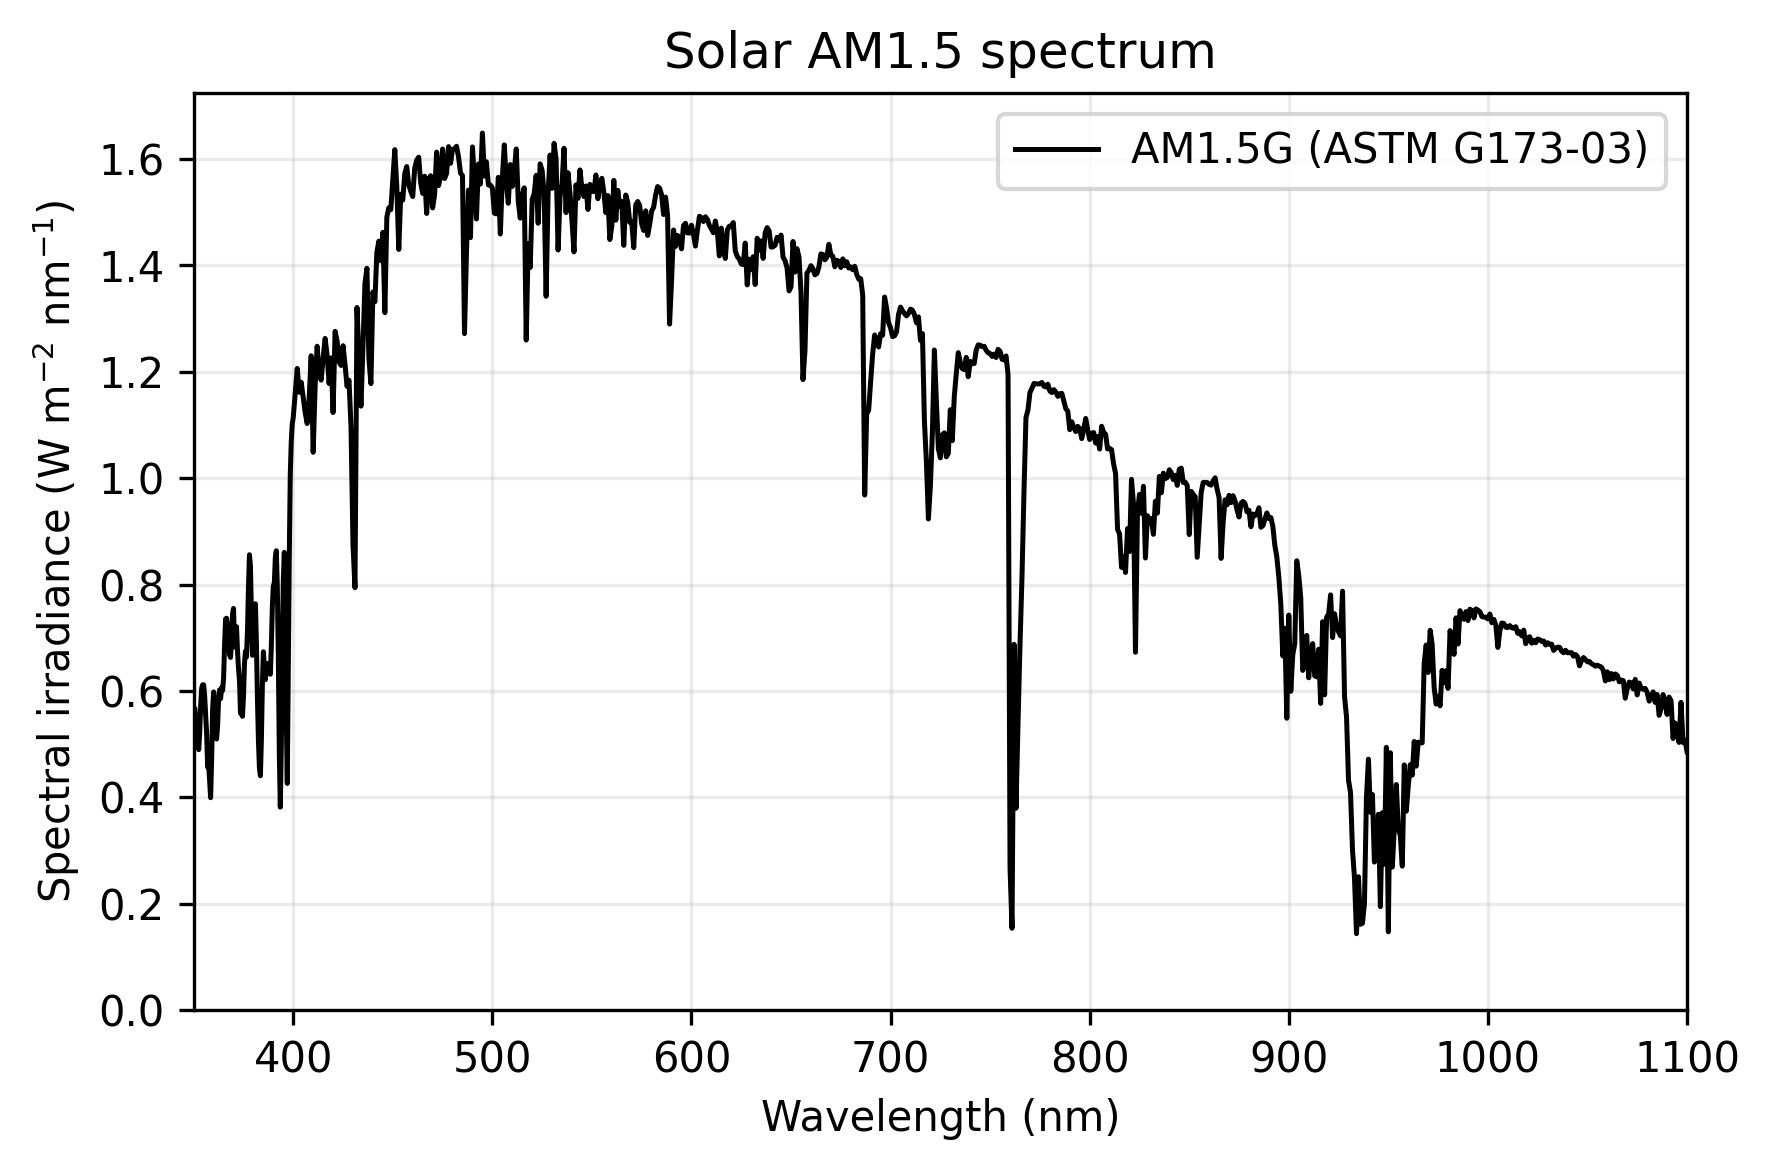

In [35]:
import pvlib
from matplotlib import cm
from matplotlib.colors import Normalize

am15 = pvlib.spectrum.get_reference_spectra(standard='ASTM G173-03')
wl_am15 = am15.index.to_numpy(dtype=float)
I_am15 = am15['global'].to_numpy(dtype=float)  # W m^-2 nm^-1

mask_plot = (wl_am15 >= 350) & (wl_am15 <= 1100)
wl_plot = wl_am15[mask_plot]
I_plot = I_am15[mask_plot]

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

ax.plot(wl_plot, I_plot, color='black', lw=1.2, label='AM1.5G (ASTM G173-03)')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Spectral irradiance (W m$^{-2}$ nm$^{-1}$)')
ax.set_title('Solar AM1.5 spectrum')
ax.set_xlim(350, 1100)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig('plots/AM1.5_spectrum.png', dpi=300)
plt.show()


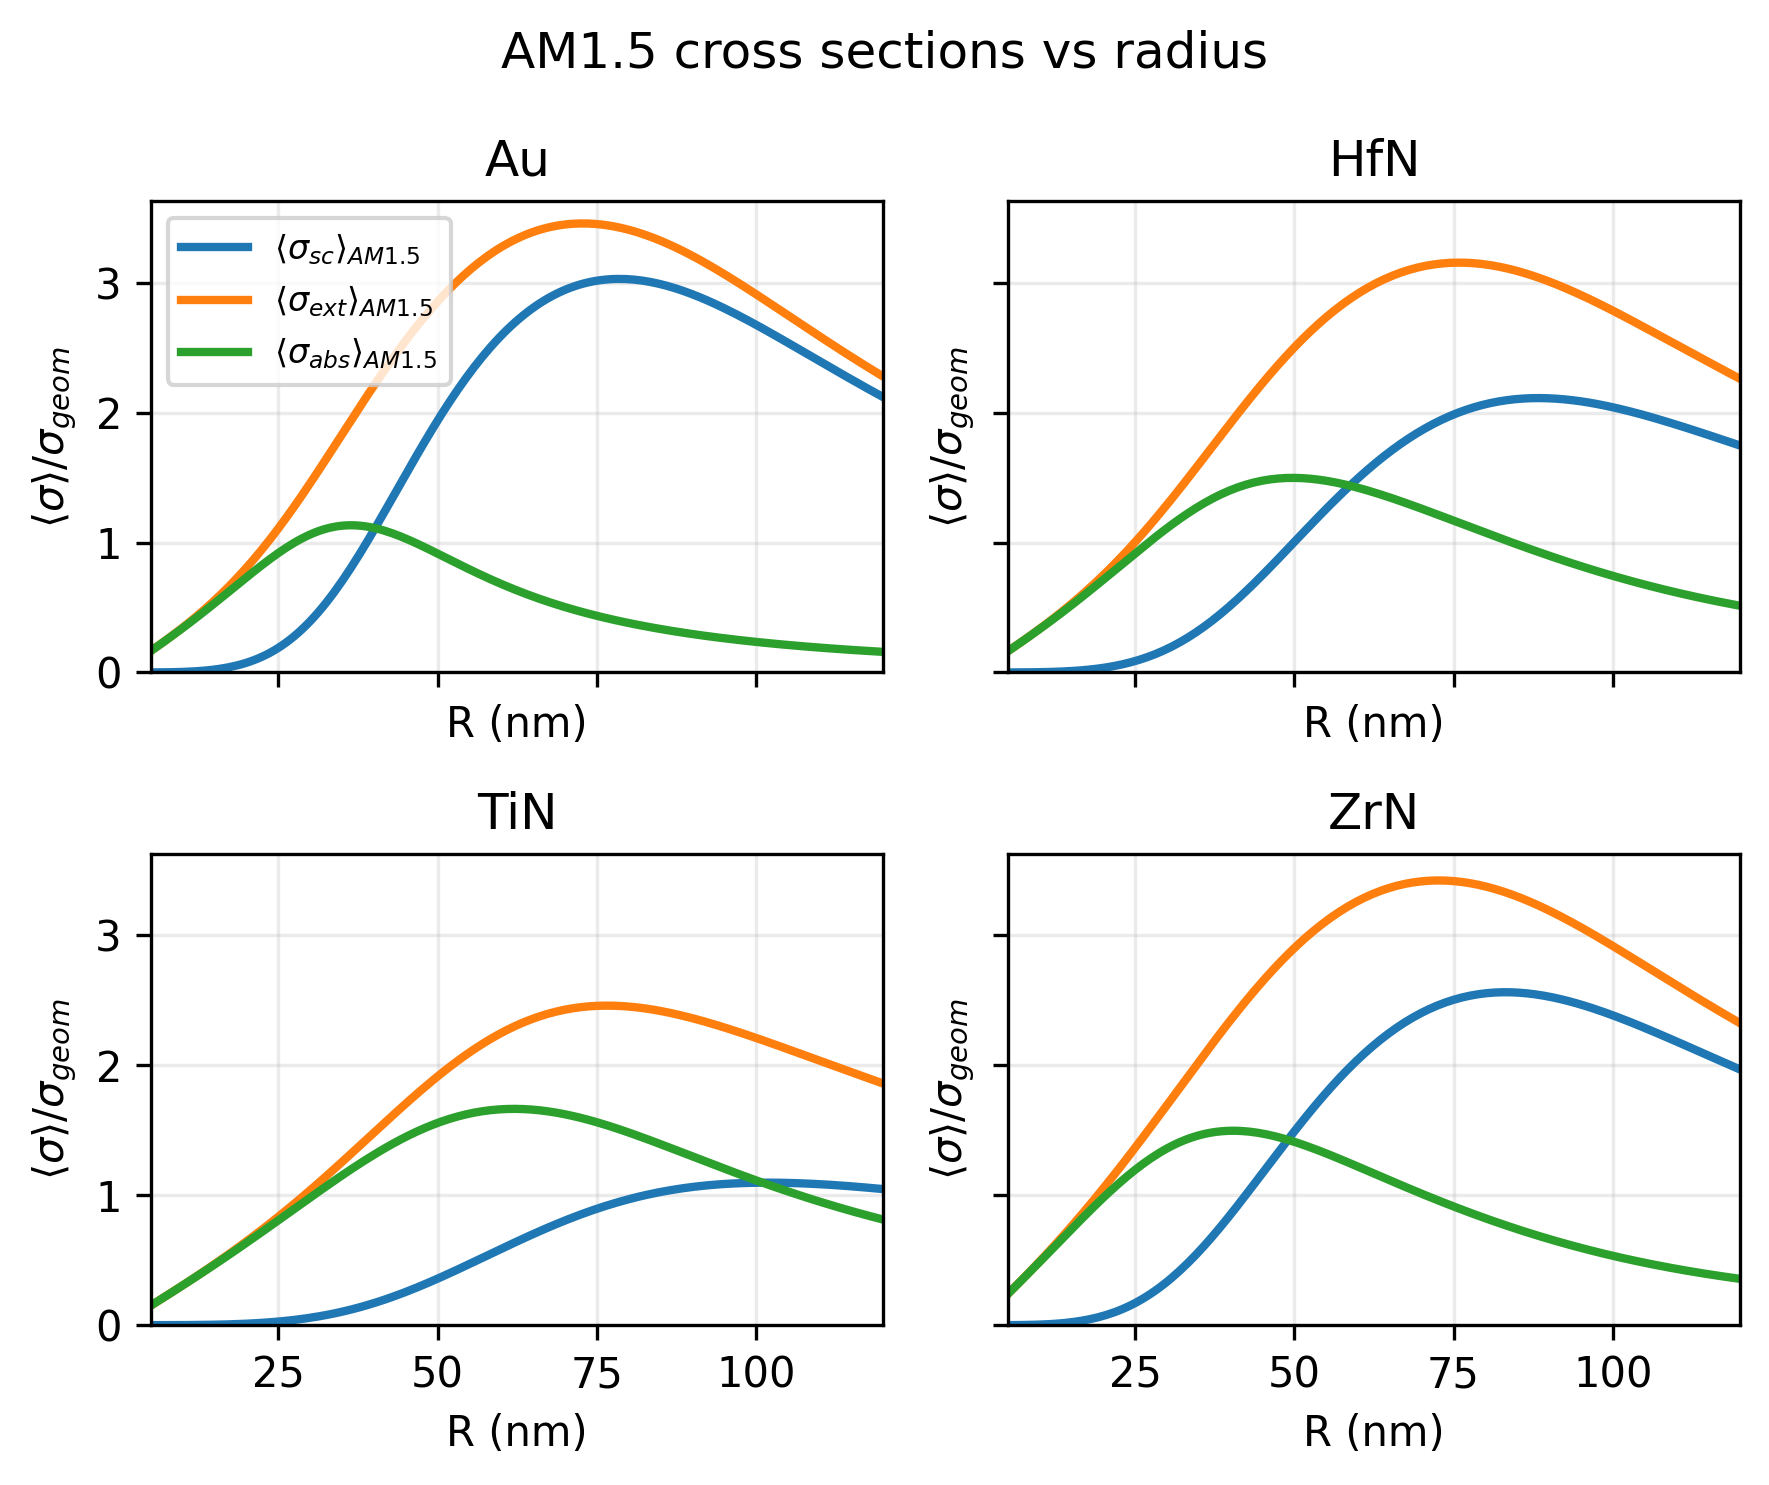

In [34]:
wls_cs = np.linspace(420, 950, 800)
R_values = np.linspace(5, 120, 180) 

I_cs = np.interp(wls_cs, wl_am15, I_am15)
I_norm = np.trapezoid(I_cs, wls_cs)

results = {}
fig, axes = plt.subplots(2, 2, figsize=(6, 5), dpi=300, sharey=True, sharex=True)
axes = axes.ravel()

for i, mat in enumerate(mats):
    eps = get_interpolate(mat)
    n_medium = media[i]
    eps_m = n_medium**2

    Csca_sun_R = np.zeros_like(R_values)
    Cext_sun_R = np.zeros_like(R_values)
    Cabs_sun_R = np.zeros_like(R_values)

    for j, R_particle in enumerate(R_values):
        Csca, Cext, Cabs = cross_sections(wls_cs, R_particle, eps, eps_m=eps_m)
        Csca_sun_R[j] = np.trapezoid(I_cs * Csca, wls_cs) / I_norm
        Cext_sun_R[j] = np.trapezoid(I_cs * Cext, wls_cs) / I_norm
        Cabs_sun_R[j] = np.trapezoid(I_cs * Cabs, wls_cs) / I_norm

    ratio_abs_ext_R = np.divide(
        Cabs_sun_R,
        Cext_sun_R,
        out=np.zeros_like(Cabs_sun_R),
        where=np.abs(Cext_sun_R) > 1e-15
    )

    results[mat] = {
        'R': R_values.copy(),
        'Csca': Csca_sun_R,
        'Cext': Cext_sun_R,
        'Cabs': Cabs_sun_R,
        'ratio': ratio_abs_ext_R,
        'n_medium': n_medium,
    }

    ax = axes[i]
    ax.plot(R_values, Csca_sun_R, lw=2, label='$\\langle\\sigma_{sc}\\rangle_{AM1.5}$')
    ax.plot(R_values, Cext_sun_R, lw=2, label='$\\langle\\sigma_{ext}\\rangle_{AM1.5}$')
    ax.plot(R_values, Cabs_sun_R, lw=2, label='$\\langle\\sigma_{abs}\\rangle_{AM1.5}$')
    ax.set_xlim(R_values[0], R_values[-1])
    ax.set_ylim(bottom=0)
    ax.set_title(f"{mat}")
    ax.set_xlabel('R (nm)')
    ax.set_ylabel('$\\langle\\sigma\\rangle/\\sigma_{geom}$')
    ax.grid(alpha=0.25)

axes[0].legend(loc='best', fontsize=8)
fig.suptitle('AM1.5 cross sections vs radius')
plt.tight_layout()
plt.savefig('plots/cross_sections_AM1.5_comparison.png', dpi=300)
plt.show()

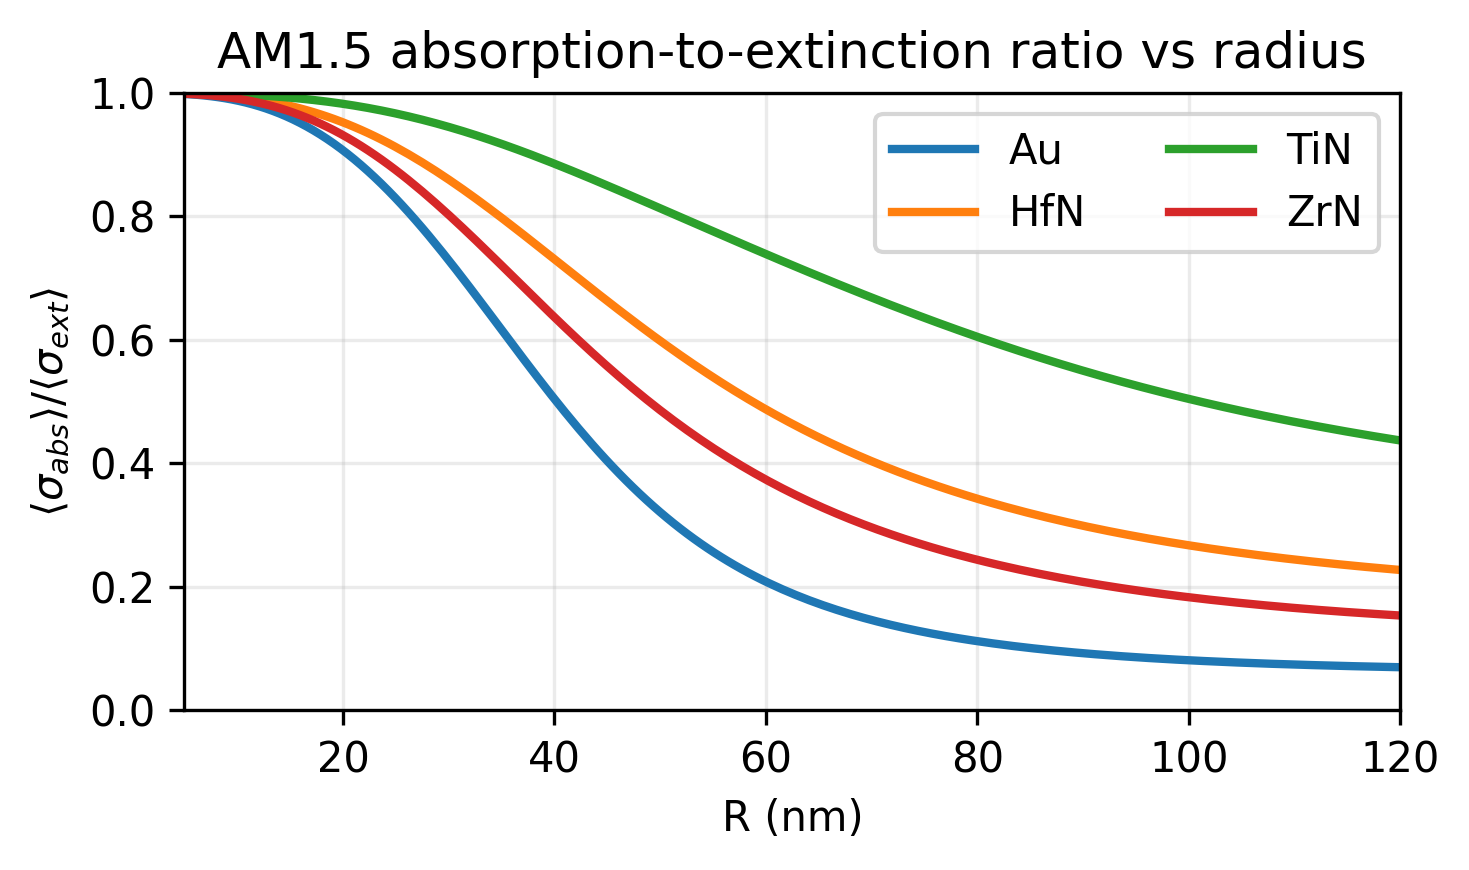

In [28]:
plt.figure(figsize=(5, 3), dpi=300)
for mat in mats:
    plt.plot(results[mat]['R'], results[mat]['ratio'], lw=2, label=f"{mat}")

plt.xlabel('R (nm)')
plt.ylabel('$\\langle\\sigma_{abs}\\rangle / \\langle\\sigma_{ext}\\rangle$')
plt.title('AM1.5 absorption-to-extinction ratio vs radius')
plt.xlim(R_values[0], R_values[-1])
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.legend(ncol=2)
plt.tight_layout()
plt.savefig('plots/abs_ext_ratio_AM1.5_comparison.png', dpi=300)
plt.show()

### Let us consider that, as the particle size increases, some of the light is absorbed in the colloidal solution

Using Beer–Lambert law:

$$
I(x, \lambda) = I_0(\lambda) e^{- N \sigma_{ext}(\lambda) x},
$$
where $N$ is concentration of plasmonic particles.

In layer of thickness L we have:

$$
I(L, \lambda ) = I_0(\lambda) (1 - e^{- N \sigma_{ext}(\lambda) x})
$$

Ratio between absorbed light defined as:

$$
f(\lambda) = \dfrac{\sigma_{abs} (\lambda)}{\sigma_{ext}(\lambda)}
$$

Resulting we have power absorbed in layer of thickess :

$$
P_{abs} = \int \frac{\sigma_{abs}}{\sigma_{ext}} (\lambda) I_0(\lambda) (1 - e^{- N \sigma_{ext}(\lambda) x} ) d \lambda
$$

Efficency
$$
\eta = \dfrac{P_{abs}}{P_{in}}
$$

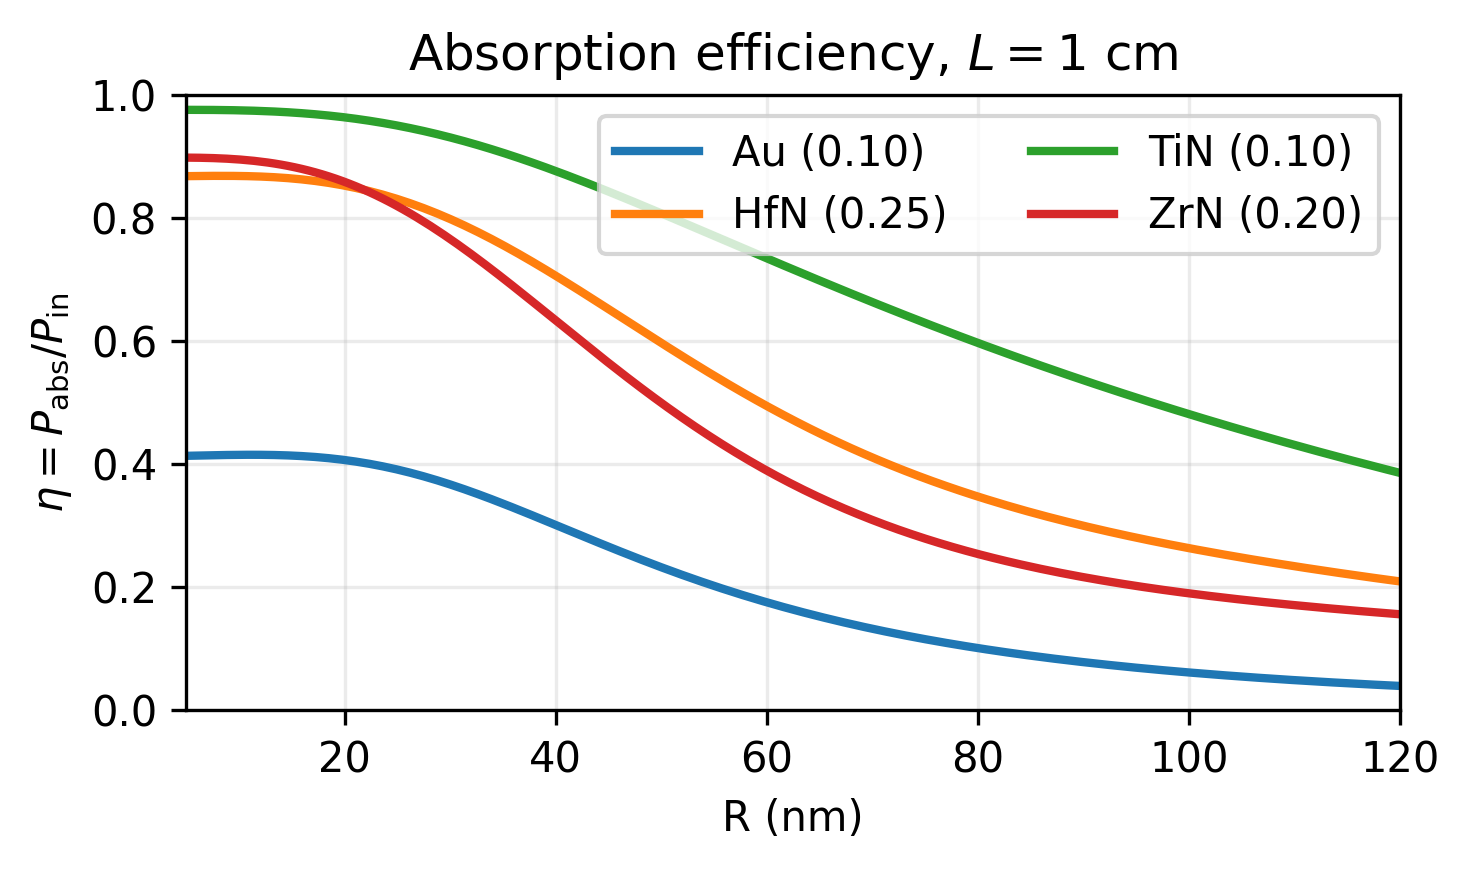

In [51]:
L_m = 1e-2
L_m = 1e-2
c_mass_mg_ml = {'Au': 0.10, 'HfN': 0.25, 'TiN': 0.10, 'ZrN': 0.20}
rho_g_cm3 = {'Au': 19.32, 'HfN': 13.73, 'TiN': 5.22, 'ZrN': 7.09}

wl_nm = wls_cs.copy()
I0_nm = I_cs.copy()

def beer_lambert_slab(wl_nm, I0_nm, sigma_ext_m2, sigma_abs_m2, N_m3, L_m):
    wl_m = wl_nm * 1e-9
    I0_wm3 = I0_nm * 1e9

    kappa = N_m3 * sigma_ext_m2
    T = np.exp(-kappa * L_m) 
    frac_abs = sigma_abs_m2 / sigma_ext_m2,

    Pabs_wm3 = I0_wm3 * (1.0 - T) * frac_abs 

    Pabs_total = np.trapezoid(Pabs_wm3, wl_m)
    Pin = np.trapezoid(I0_wm3, wl_m)
    eta = Pabs_total / Pin if Pin > 0 else np.nan

    return eta

eta_curves = {}

for i, mat in enumerate(mats):
    eps = get_interpolate(mat)
    eps_m = media[i] ** 2
    c_mass_kg_m3 = c_mass_mg_ml[mat]
    rho_kg_m3 = rho_g_cm3[mat] * 1000.0
    eta_R = np.zeros_like(R_values, dtype=float)

    for j, R_nm in enumerate(R_values):
        R_m = R_nm * 1e-9
        V_particle = 4.0 / 3.0 * np.pi * R_m**3
        m_particle = rho_kg_m3 * V_particle
        N_m3 = c_mass_kg_m3 / m_particle
        Qsca, Qext, Qabs = cross_sections(wl_nm, R_nm, eps, eps_m=eps_m)
        C_geom = np.pi * (R_nm * 1e-9) ** 2
        sigma_ext = np.clip(np.real(Qext), 0.0, None) * C_geom
        sigma_abs = np.clip(np.real(Qabs), 0.0, None) * C_geom

        res = beer_lambert_slab(wl_nm, I0_nm, sigma_ext, sigma_abs, N_m3, L_m)
        eta_R[j] = float(np.asarray(res).squeeze())

    eta_curves[mat] = eta_R

plt.figure(figsize=(5, 3), dpi=300)
for mat in mats:
    plt.plot(R_values, eta_curves[mat], lw=2, label=f"{mat} ({c_mass_mg_ml[mat]:.2f})")

plt.xlabel("R (nm)")
plt.ylabel(r"$\eta = P_{\rm abs}/P_{\rm in}$")
plt.title(rf"Absorption efficiency, $L=1$ cm")
plt.xlim(R_values[0], R_values[-1])
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.legend(ncol=2)
plt.tight_layout()
plt.savefig("plots/abs_efficiency_in_layer.png", dpi=300)
plt.show()